In [1]:
import tkinter as tk
import random
import math
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt

# --- Modern Dark Theme Colors ---
BG_DARK = "#121212"
BG_CARD = "#1e1e1e"
TEXT_WHITE = "#ffffff"
TEXT_GRAY = "#a0a0a0"
ACCENT_GREEN = "#00ff00"
ACCENT_ORANGE = "#ff9900"
BTN_BUY = "#28a745"
BTN_SELL = "#dc3545"
BTN_RESET = "#007bff"
CHART_BG = "#003300"
AXES_BG = "#002200"

# --- Player Card Theme Colors ---
USER_CARD_BG = "#0d1b2a"
USER_ACCENT = "#3399ff"
BOT_CARD_BG = "#240046"
BOT_ACCENT = "#b366ff"

# --- Game Rules ---
TRADE_FEE = 1.00

class ModernTradingGame:
    def __init__(self, root):
        self.root = root
        self.root.title("Bot vs. Brain: The Quant Challenge")
        self.root.geometry("900x950")
        self.root.configure(bg=BG_DARK)

        # Game & Market Variables
        self.time_left = 60
        self.is_game_over = False
        self.is_running = False
        self.price = 100.0
        self.price_history = [100.0] * 30
        self.sma_history = [100.0] * 30
        self.loop_id = None
        self.flash_id = None
        self.is_flashing = False

        # Geometric Brownian Motion Parameters
        self.mu = 0.005    # Drift (slight upward bias)
        self.sigma = 0.04  # Volatility
        self.dt = 1.0      # Time step

        # Player Portfolios & Stats Tracking
        self.user_cash = 1000.0
        self.user_shares = 0
        self.user_stats = {'bought': 0, 'spent': 0.0, 'sold': 0, 'earned': 0.0, 'fees': 0.0}

        self.bot_cash = 1000.0
        self.bot_shares = 0
        self.bot_stats = {'bought': 0, 'spent': 0.0, 'sold': 0, 'earned': 0.0, 'fees': 0.0}

        # --- SCROLLABLE CONTAINER SETUP ---
        self.main_container = tk.Frame(root, bg=BG_DARK)
        self.main_container.pack(fill=tk.BOTH, expand=True)

        self.main_canvas = tk.Canvas(self.main_container, bg=BG_DARK, highlightthickness=0)
        self.scrollbar = tk.Scrollbar(self.main_container, orient="vertical", command=self.main_canvas.yview)

        self.scroll_frame = tk.Frame(self.main_canvas, bg=BG_DARK)

        self.scroll_frame.bind(
            "<Configure>",
            lambda e: self.main_canvas.configure(scrollregion=self.main_canvas.bbox("all"))
        )

        self.frame_id = self.main_canvas.create_window((0, 0), window=self.scroll_frame, anchor="nw")

        self.main_canvas.bind(
            '<Configure>',
            lambda e: self.main_canvas.itemconfig(self.frame_id, width=e.width)
        )

        self.main_canvas.configure(yscrollcommand=self.scrollbar.set)

        self.main_canvas.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)
        self.scrollbar.pack(side=tk.RIGHT, fill=tk.Y)

        # Enable Mousewheel Scrolling
        def _on_mousewheel(event):
            self.main_canvas.yview_scroll(int(-1*(event.delta/120)), "units")
        self.root.bind_all("<MouseWheel>", _on_mousewheel)

        # --- UI SETUP ---

        # 1. Large Top-Center Digital Clock
        self.timer_label = tk.Label(self.scroll_frame, text=f"00:{self.time_left:02d}", font=("Courier New", 56, "bold"), fg=TEXT_WHITE, bg=BG_DARK)
        self.timer_label.pack(pady=(20, 0))

        # 2. Header with Inline Menu Controls
        self.header_frame = tk.Frame(self.scroll_frame, bg=BG_DARK)
        self.header_frame.pack(pady=(5, 10), fill=tk.X, padx=20)

        # Inline control menu replacing the top bar
        self.controls_frame = tk.Frame(self.header_frame, bg=BG_DARK)
        self.controls_frame.pack(side=tk.LEFT)

        self.start_btn = tk.Button(self.controls_frame, text="▶ START", bg=BTN_BUY, fg=TEXT_WHITE, font=("Segoe UI", 12, "bold"), relief=tk.FLAT, borderwidth=0, command=self.start_game)
        self.start_btn.pack(side=tk.LEFT, padx=(0, 5))

        self.pause_btn = tk.Button(self.controls_frame, text="⏸ PAUSE", bg="#555555", fg=TEXT_WHITE, font=("Segoe UI", 12, "bold"), relief=tk.FLAT, borderwidth=0, command=self.stop_game, state=tk.DISABLED)
        self.pause_btn.pack(side=tk.LEFT, padx=(0, 5))

        self.mid_restart_btn = tk.Button(self.controls_frame, text="↻ RESTART", bg=BTN_RESET, fg=TEXT_WHITE, font=("Segoe UI", 12, "bold"), relief=tk.FLAT, borderwidth=0, command=self.reset_game)
        self.mid_restart_btn.pack(side=tk.LEFT)

        tk.Label(self.header_frame, text="BOT VS. BRAIN", font=("Segoe UI", 24, "bold"), fg=TEXT_WHITE, bg=BG_DARK).pack(side=tk.LEFT, expand=True)
        tk.Label(self.header_frame, text="                           ", bg=BG_DARK).pack(side=tk.RIGHT) # Spacer to keep title centered

        # 3. Modern Green Matplotlib Chart
        self.fig = Figure(figsize=(9, 4), dpi=100, facecolor=CHART_BG)
        self.ax = self.fig.add_subplot(111, facecolor=AXES_BG)

        self.ax.tick_params(axis='x', colors=CHART_BG)
        self.ax.tick_params(axis='y', colors=ACCENT_GREEN, labelsize=10)
        self.ax.spines['bottom'].set_color(CHART_BG)
        self.ax.spines['top'].set_color(CHART_BG)
        self.ax.spines['left'].set_color(ACCENT_GREEN)
        self.ax.spines['right'].set_color(CHART_BG)
        self.ax.grid(True, color=ACCENT_GREEN, linestyle=':', linewidth=0.5, alpha=0.5)

        self.canvas = FigureCanvasTkAgg(self.fig, master=self.scroll_frame)
        self.canvas.get_tk_widget().pack(pady=10, padx=20, fill=tk.BOTH, expand=True)

        # 4. Modern Scoreboard Card
        self.score_card = tk.Frame(self.scroll_frame, bg=BG_CARD, padx=20, pady=20)
        self.score_card.pack(pady=10, padx=20, fill=tk.X)

        self.price_label = tk.Label(self.score_card, text=f"₹{self.price:.2f}", font=("Segoe UI", 32, "bold"), fg=ACCENT_GREEN, bg=BG_CARD)
        self.price_label.pack()
        tk.Label(self.score_card, text="CURRENT PRICE", font=("Segoe UI", 10), fg=TEXT_GRAY, bg=BG_CARD).pack(pady=(0, 10))

        # --- TUG OF WAR BAR ---
        self.tow_frame = tk.Frame(self.score_card, bg=BG_CARD)
        self.tow_frame.pack(fill=tk.X, pady=(5, 15))
        self.tow_canvas = tk.Canvas(self.tow_frame, height=20, bg=BG_DARK, highlightthickness=0)
        self.tow_canvas.pack(fill=tk.X, expand=True)
        self.tow_canvas.bind("<Configure>", lambda e: self.draw_tug_of_war())

        stats_frame = tk.Frame(self.score_card, bg=BG_CARD)
        stats_frame.pack(fill=tk.X, pady=5)

        # USER CARD
        user_card = tk.Frame(stats_frame, bg=USER_CARD_BG, highlightbackground=USER_ACCENT, highlightthickness=2, padx=15, pady=10)
        user_card.pack(side=tk.LEFT, fill=tk.BOTH, expand=True, padx=(0, 10))

        tk.Label(user_card, text="👤 HUMAN TRADER", font=("Segoe UI", 12, "bold"), fg=USER_ACCENT, bg=USER_CARD_BG).pack(anchor="w")
        self.user_val_label = tk.Label(user_card, text="₹1000.00", font=("Segoe UI", 26, "bold"), fg=TEXT_WHITE, bg=USER_CARD_BG)
        self.user_val_label.pack(anchor="w", pady=5)
        self.user_details = tk.Label(user_card, text="Cash: ₹1000.00  |  Shares: 0", font=("Segoe UI", 11), fg=TEXT_GRAY, bg=USER_CARD_BG)
        self.user_details.pack(anchor="w")

        # BOT CARD
        bot_card = tk.Frame(stats_frame, bg=BOT_CARD_BG, highlightbackground=BOT_ACCENT, highlightthickness=2, padx=15, pady=10)
        bot_card.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True, padx=(10, 0))

        tk.Label(bot_card, text="🤖 ALGO BOT", font=("Segoe UI", 12, "bold"), fg=BOT_ACCENT, bg=BOT_CARD_BG).pack(anchor="e")
        self.bot_val_label = tk.Label(bot_card, text="₹1000.00", font=("Segoe UI", 26, "bold"), fg=TEXT_WHITE, bg=BOT_CARD_BG)
        self.bot_val_label.pack(anchor="e", pady=5)
        self.bot_details = tk.Label(bot_card, text="Cash: ₹1000.00  |  Shares: 0", font=("Segoe UI", 11), fg=TEXT_GRAY, bg=BOT_CARD_BG)
        self.bot_details.pack(anchor="e")

        # 5. Modern Trading Controls
        self.btn_frame = tk.Frame(self.scroll_frame, bg=BG_DARK)
        self.btn_frame.pack(pady=10)

        tk.Label(self.btn_frame, text=f"⚠️ {TRADE_FEE:.2f} Commission per Trade", font=("Segoe UI", 10, "italic"), fg=BTN_SELL, bg=BG_DARK).grid(row=0, column=0, columnspan=2, pady=(0, 5))

        self.buy_btn = tk.Button(self.btn_frame, text="BUY", bg=BTN_BUY, fg=TEXT_WHITE, font=("Segoe UI", 16, "bold"), width=12, relief=tk.FLAT, borderwidth=0, command=self.user_buy)
        self.buy_btn.grid(row=1, column=0, padx=15)

        self.sell_btn = tk.Button(self.btn_frame, text="SELL", bg=BTN_SELL, fg=TEXT_WHITE, font=("Segoe UI", 16, "bold"), width=12, relief=tk.FLAT, borderwidth=0, command=self.user_sell)
        self.sell_btn.grid(row=1, column=1, padx=15)

        # 6. Game Over & Stats Section
        self.game_over_frame = tk.Frame(self.scroll_frame, bg=BG_DARK)
        self.game_over_frame.pack(pady=10, fill=tk.X)

        self.winner_label = tk.Label(self.game_over_frame, text="", font=("Segoe UI", 20, "bold"), bg=BG_DARK)
        self.winner_label.pack(pady=5)

        # --- POST-GAME STATS PANEL ---
        self.stats_panel = tk.Frame(self.game_over_frame, bg=BG_CARD, padx=20, pady=10)

        tk.Label(self.stats_panel, text="Metric", font=("Segoe UI", 12, "bold"), fg=TEXT_GRAY, bg=BG_CARD).grid(row=0, column=0, sticky="w", padx=20, pady=5)
        tk.Label(self.stats_panel, text="HUMAN", font=("Segoe UI", 12, "bold"), fg=USER_ACCENT, bg=BG_CARD).grid(row=0, column=1, padx=20, pady=5)
        tk.Label(self.stats_panel, text="BOT", font=("Segoe UI", 12, "bold"), fg=BOT_ACCENT, bg=BG_CARD).grid(row=0, column=2, padx=20, pady=5)

        metrics = ["Shares Bought", "Avg Buy Price", "Shares Sold", "Total Fees Paid", "Total Net P/L"]
        for i, metric in enumerate(metrics):
            tk.Label(self.stats_panel, text=metric, font=("Segoe UI", 11), fg=TEXT_WHITE, bg=BG_CARD).grid(row=i+1, column=0, sticky="w", padx=20, pady=2)

        self.stat_u_bought = tk.Label(self.stats_panel, text="0", font=("Segoe UI", 11), fg=TEXT_WHITE, bg=BG_CARD)
        self.stat_u_bought.grid(row=1, column=1)
        self.stat_b_bought = tk.Label(self.stats_panel, text="0", font=("Segoe UI", 11), fg=TEXT_WHITE, bg=BG_CARD)
        self.stat_b_bought.grid(row=1, column=2)

        self.stat_u_avg = tk.Label(self.stats_panel, text="₹0.00", font=("Segoe UI", 11), fg=TEXT_WHITE, bg=BG_CARD)
        self.stat_u_avg.grid(row=2, column=1)
        self.stat_b_avg = tk.Label(self.stats_panel, text="₹0.00", font=("Segoe UI", 11), fg=TEXT_WHITE, bg=BG_CARD)
        self.stat_b_avg.grid(row=2, column=2)

        self.stat_u_sold = tk.Label(self.stats_panel, text="0", font=("Segoe UI", 11), fg=TEXT_WHITE, bg=BG_CARD)
        self.stat_u_sold.grid(row=3, column=1)
        self.stat_b_sold = tk.Label(self.stats_panel, text="0", font=("Segoe UI", 11), fg=TEXT_WHITE, bg=BG_CARD)
        self.stat_b_sold.grid(row=3, column=2)

        self.stat_u_fees = tk.Label(self.stats_panel, text="-₹0.00", font=("Segoe UI", 11), fg=BTN_SELL, bg=BG_CARD)
        self.stat_u_fees.grid(row=4, column=1)
        self.stat_b_fees = tk.Label(self.stats_panel, text="-₹0.00", font=("Segoe UI", 11), fg=BTN_SELL, bg=BG_CARD)
        self.stat_b_fees.grid(row=4, column=2)

        self.stat_u_pl = tk.Label(self.stats_panel, text="₹0.00", font=("Segoe UI", 11, "bold"), fg=TEXT_WHITE, bg=BG_CARD)
        self.stat_u_pl.grid(row=5, column=1)
        self.stat_b_pl = tk.Label(self.stats_panel, text="₹0.00", font=("Segoe UI", 11, "bold"), fg=TEXT_WHITE, bg=BG_CARD)
        self.stat_b_pl.grid(row=5, column=2)

        self.reset_btn = tk.Button(self.game_over_frame, text="PLAY AGAIN", bg=BTN_RESET, fg=TEXT_WHITE, font=("Segoe UI", 16, "bold"), width=18, relief=tk.FLAT, borderwidth=0, command=self.reset_game)

        # Draw initial state and wait for the user to press start
        self.draw_paused_chart()
        self.update_labels()

    # --- START / STOP LOGIC ---
    def start_game(self):
        if not self.is_running and not self.is_game_over:
            self.is_running = True
            self.start_btn.config(state=tk.DISABLED, bg="#555555")
            self.pause_btn.config(state=tk.NORMAL, bg=ACCENT_ORANGE)
            self.update_market()

    def stop_game(self):
        self.is_running = False
        self.start_btn.config(state=tk.NORMAL, bg=BTN_BUY)
        self.pause_btn.config(state=tk.DISABLED, bg="#555555")

        if self.loop_id:
            self.root.after_cancel(self.loop_id)
            self.loop_id = None
        if self.flash_id:
            self.root.after_cancel(self.flash_id)
            self.flash_id = None
            self.timer_label.config(fg=TEXT_WHITE)
        self.draw_paused_chart()

    def draw_paused_chart(self):
        if self.is_game_over: return
        self.ax.clear()
        self.ax.set_title("MARKET PAUSED - PRESS START TO RESUME", color=ACCENT_ORANGE, fontname="Segoe UI", fontsize=12, pad=10)
        self.ax.plot(self.price_history, color=ACCENT_GREEN, label="Price", linewidth=2.5)
        self.ax.plot(self.sma_history, color=ACCENT_ORANGE, label="Bot (SMA)", linestyle='--', linewidth=2)
        self.ax.legend(loc="upper left", facecolor=AXES_BG, edgecolor=ACCENT_GREEN, labelcolor=TEXT_WHITE)
        self.ax.grid(True, color=ACCENT_GREEN, linestyle=':', linewidth=0.5, alpha=0.5)
        self.canvas.draw()

    # --- TUG OF WAR DRAWING LOGIC ---
    def draw_tug_of_war(self):
        c_width = self.tow_canvas.winfo_width()
        if c_width <= 1: return

        user_val = self.user_cash + (self.user_shares * self.price)
        bot_val = self.bot_cash + (self.bot_shares * self.price)
        total_val = user_val + bot_val

        human_pct = user_val / total_val if total_val > 0 else 0.5
        h_width = c_width * human_pct

        self.tow_canvas.delete("all")
        self.tow_canvas.create_rectangle(0, 0, h_width, 20, fill=USER_ACCENT, outline="")
        self.tow_canvas.create_rectangle(h_width, 0, c_width, 20, fill=BOT_ACCENT, outline="")
        self.tow_canvas.create_line(c_width/2, 0, c_width/2, 20, fill=TEXT_WHITE, dash=(4, 4), width=2)

    # --- LOGIC & UPDATES ---
    def flash_clock(self):
        if self.is_game_over or not self.is_flashing:
            self.timer_label.config(fg=TEXT_WHITE)
            return

        current_color = self.timer_label.cget("fg")
        new_color = "#ff0000" if current_color == TEXT_WHITE else TEXT_WHITE
        self.timer_label.config(fg=new_color)

        self.flash_id = self.root.after(500, self.flash_clock)

    def user_buy(self):
        total_cost = self.price + TRADE_FEE
        if not self.is_game_over and self.user_cash >= total_cost:
            self.user_cash -= total_cost
            self.user_shares += 1
            self.user_stats['bought'] += 1
            self.user_stats['spent'] += self.price
            self.user_stats['fees'] += TRADE_FEE
            self.update_labels()

    def user_sell(self):
        if not self.is_game_over and self.user_shares > 0:
            self.user_cash += (self.price - TRADE_FEE)
            self.user_shares -= 1
            self.user_stats['sold'] += 1
            self.user_stats['earned'] += self.price
            self.user_stats['fees'] += TRADE_FEE
            self.update_labels()

    def bot_logic(self, current_sma):
        if self.is_game_over: return

        total_buy_cost = self.price + TRADE_FEE
        if self.price > current_sma and self.bot_cash >= total_buy_cost:
            self.bot_cash -= total_buy_cost
            self.bot_shares += 1
            self.bot_stats['bought'] += 1
            self.bot_stats['spent'] += self.price
            self.bot_stats['fees'] += TRADE_FEE
        elif self.price < current_sma and self.bot_shares > 0:
            self.bot_cash += (self.price - TRADE_FEE)
            self.bot_shares -= 1
            self.bot_stats['sold'] += 1
            self.bot_stats['earned'] += self.price
            self.bot_stats['fees'] += TRADE_FEE

    def end_game(self):
        self.is_game_over = True
        self.is_running = False
        self.is_flashing = False
        if self.flash_id:
            self.root.after_cancel(self.flash_id)

        self.timer_label.config(text="00:00", fg=BTN_SELL)
        self.buy_btn.config(state=tk.DISABLED, bg="#555555")
        self.sell_btn.config(state=tk.DISABLED, bg="#555555")

        # Disable top menu buttons too
        self.start_btn.config(state=tk.DISABLED, bg="#555555")
        self.pause_btn.config(state=tk.DISABLED, bg="#555555")

        user_val = self.user_cash + (self.user_shares * self.price)
        bot_val = self.bot_cash + (self.bot_shares * self.price)

        if user_val > bot_val:
            result_text = "🎉 YOU WIN! BEAT THE MACHINE! 🎉"
            color = BTN_BUY
        elif bot_val > user_val:
            result_text = "💀 BOT WINS. FEES & EMOTION KILL RETURNS. 💀"
            color = BTN_SELL
        else:
            result_text = "🤝 DRAW. A RARE TIE. 🤝"
            color = BTN_RESET

        self.winner_label.config(text=result_text, fg=color)

        # Calculate and Display Stats
        u_avg = self.user_stats['spent'] / self.user_stats['bought'] if self.user_stats['bought'] > 0 else 0
        b_avg = self.bot_stats['spent'] / self.bot_stats['bought'] if self.bot_stats['bought'] > 0 else 0

        u_pl = user_val - 1000.0
        b_pl = bot_val - 1000.0

        self.stat_u_bought.config(text=str(self.user_stats['bought']))
        self.stat_b_bought.config(text=str(self.bot_stats['bought']))

        self.stat_u_avg.config(text=f"₹{u_avg:.2f}")
        self.stat_b_avg.config(text=f"₹{b_avg:.2f}")

        self.stat_u_sold.config(text=str(self.user_stats['sold']))
        self.stat_b_sold.config(text=str(self.bot_stats['sold']))

        self.stat_u_fees.config(text=f"-₹{self.user_stats['fees']:.2f}")
        self.stat_b_fees.config(text=f"-₹{self.bot_stats['fees']:.2f}")

        self.stat_u_pl.config(text=f"₹{u_pl:.2f}", fg=ACCENT_GREEN if u_pl >= 0 else BTN_SELL)
        self.stat_b_pl.config(text=f"₹{b_pl:.2f}", fg=ACCENT_GREEN if b_pl >= 0 else BTN_SELL)

        self.stats_panel.pack(pady=10)
        self.reset_btn.pack(pady=15)

        self.scroll_frame.update_idletasks()
        self.main_canvas.configure(scrollregion=self.main_canvas.bbox("all"))

    def reset_game(self):
        self.stop_game()

        self.time_left = 60
        self.is_game_over = False
        self.is_flashing = False
        self.price = 100.0
        self.price_history = [100.0] * 30
        self.sma_history = [100.0] * 30

        self.user_cash = 1000.0
        self.user_shares = 0
        self.user_stats = {'bought': 0, 'spent': 0.0, 'sold': 0, 'earned': 0.0, 'fees': 0.0}

        self.bot_cash = 1000.0
        self.bot_shares = 0
        self.bot_stats = {'bought': 0, 'spent': 0.0, 'sold': 0, 'earned': 0.0, 'fees': 0.0}

        self.winner_label.config(text="")
        self.stats_panel.pack_forget()
        self.reset_btn.pack_forget()

        self.timer_label.config(text=f"00:{self.time_left:02d}", fg=TEXT_WHITE)
        self.buy_btn.config(state=tk.NORMAL, bg=BTN_BUY)
        self.sell_btn.config(state=tk.NORMAL, bg=BTN_SELL)

        # Reset top menu buttons;
        self.start_btn.config(state=tk.NORMAL, bg=BTN_BUY)
        self.pause_btn.config(state=tk.DISABLED, bg="#555555")

        self.user_val_label.config(fg=TEXT_WHITE)
        self.bot_val_label.config(fg=TEXT_WHITE)

        self.draw_paused_chart()
        self.update_labels()
        self.main_canvas.yview_moveto(0)

    def update_market(self):
        if self.is_game_over or not self.is_running: return

        self.time_left -= 1
        self.timer_label.config(text=f"00:{self.time_left:02d}")

        if self.time_left <= 15 and not self.is_flashing:
            self.is_flashing = True
            self.flash_clock()

        if self.time_left <= 0:
            self.end_game()
            self.update_labels()
            return

        # --- NORMAL GEOMETRIC BROWNIAN MOTION LOGIC ---
        Z = random.gauss(0, 1)
        drift = (self.mu - (self.sigma ** 2) / 2) * self.dt
        shock = self.sigma * math.sqrt(self.dt) * Z
        self.price = self.price * math.exp(drift + shock)

        if self.price < 1.0:
            self.price = 1.0

        self.price_history.append(self.price)
        if len(self.price_history) > 50: self.price_history.pop(0)

        current_sma = sum(self.price_history[-5:]) / 5
        self.sma_history.append(current_sma)
        if len(self.sma_history) > 50: self.sma_history.pop(0)

        self.bot_logic(current_sma)

        self.ax.clear()
        self.ax.set_title("LIVE MARKET DATA", color=ACCENT_GREEN, fontname="Segoe UI", fontsize=12, pad=10)
        self.ax.plot(self.price_history, color=ACCENT_GREEN, label="Price", linewidth=2.5)
        self.ax.plot(self.sma_history, color=ACCENT_ORANGE, label="Bot (SMA)", linestyle='--', linewidth=2)
        self.ax.legend(loc="upper left", facecolor=AXES_BG, edgecolor=ACCENT_GREEN, labelcolor=TEXT_WHITE)
        self.ax.grid(True, color=ACCENT_GREEN, linestyle=':', linewidth=0.5, alpha=0.5)
        self.canvas.draw()

        self.update_labels()
        self.loop_id = self.root.after(1000, self.update_market)

    def update_labels(self):
        self.price_label.config(text=f"₹{self.price:.2f}")

        user_val = self.user_cash + (self.user_shares * self.price)
        bot_val = self.bot_cash + (self.bot_shares * self.price)

        if user_val > bot_val:
            user_color = BTN_BUY
            bot_color = BTN_SELL
        elif bot_val > user_val:
            user_color = BTN_SELL
            bot_color = BTN_BUY
        else:
            user_color = TEXT_WHITE
            bot_color = TEXT_WHITE

        self.user_val_label.config(text=f"₹{user_val:.2f}", fg=user_color)
        self.user_details.config(text=f"Cash: ₹{self.user_cash:.2f}  |  Shares: {self.user_shares}")

        self.bot_val_label.config(text=f"₹{bot_val:.2f}", fg=bot_color)
        self.bot_details.config(text=f"Cash: ₹{self.bot_cash:.2f}  |  Shares: {self.bot_shares}")

        self.draw_tug_of_war()

if __name__ == "__main__":
    root = tk.Tk()
    app = ModernTradingGame(root)
    root.mainloop()

Critical Path: 1 -> 3 -> 4 -> 6 -> 7
Project Length: 24 days


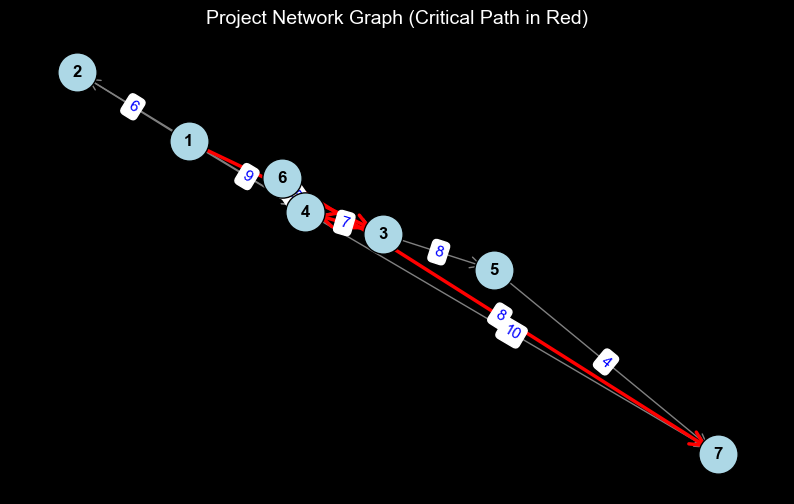

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Define the input data
# Format: (start_node, end_node, duration)
activities = [
    (1, 2, 6),
    (1, 3, 4),
    (1, 4, 9),
    (2, 4, 2),
    (3, 4, 7),
    (3, 5, 8),
    (4, 6, 5),
    (4, 7, 10),
    (5, 7, 4),
    (6, 7, 8)
]

# 2. Create a directed graph
G = nx.DiGraph()

# Add edges to the graph with their respective durations as weights
for u, v, duration in activities:
    G.add_edge(u, v, weight=duration)

# 3. Calculate Critical Path and Project Length
# The critical path is equivalent to the longest path in a Directed Acyclic Graph (DAG)
critical_path = nx.dag_longest_path(G, weight='weight')
project_length = nx.dag_longest_path_length(G, weight='weight')

print(f"Critical Path: {' -> '.join(map(str, critical_path))}")
print(f"Project Length: {project_length} days")

# 4. Visualize the Network Graph
plt.figure(figsize=(10, 6))

# Define a layout for the nodes
pos = nx.spring_layout(G, seed=42)

# Draw all standard nodes and edges
nx.draw_networkx_nodes(G, pos, node_size=800, node_color="lightblue", edgecolors="black")
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20, edge_color="gray")

# Highlight the critical path edges in red
critical_edges = [(critical_path[i], critical_path[i+1]) for i in range(len(critical_path)-1)]
nx.draw_networkx_edges(G, pos, edgelist=critical_edges, arrowstyle="->", arrowsize=25, edge_color="red", width=2.5)

# Add node labels (1, 2, 3...)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")

# Add edge weights (durations)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, font_color="blue")

plt.title("Project Network Graph (Critical Path in Red)", fontsize=14)
plt.axis("off") # Hide grid axes
plt.show()